# Ten internal nodes along the human tree

`01`-`04` use three nodes. This one widens to ten reconstructed nodes that were picked
for a reason: after the class 1 / class 2 split, `node_6 -> 12 -> 21 -> 32 -> 44` is a
nested chain descending the class 2 trunk, so the repertoire can be followed step by
step down a single lineage rather than compared across a fork.

Same density fill as the rest of the folder. Only reconstructed nodes appear here;
extant receptors enter in `03` and `04`.

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, \
                           decay_table, edge_table, node_topology, node_sets, \
                           save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, TEN_NODES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

# ten CVD-safe categorical colours, fixed order
PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7",
       "#e34948", "#e87ba4", "#eb6834", "#0098c7", "#9c4d00"]
NCOL = {n: PAL[i] for i, n in enumerate(TEN_NODES)}
THRESH = None   # None = shared density fill; a number restores an absolute cut

topo = node_topology(TEN_NODES, threshold=THRESH)
sets = node_sets(TEN_NODES, threshold=THRESH)
print(topo.to_string(index=False))
save_table(topo, "05_topology")

 node  parent  depth  branch_len  n_leaves  frac_class_I OR_class  n_ligands  n_retained  n_gained  n_lost ancestors_in_set
    1  node_0      1    1.512110       433         0.143    mixed         21         NaN       NaN     NaN                 
    2  node_1      2    0.487478        62         1.000  Class_I         21         4.0      17.0    17.0                1
    3  node_1      2    0.357385       371         0.000 Class_II          8         7.0       1.0    14.0                1
    4  node_2      3    0.473190        55         1.000  Class_I         23        12.0      11.0     9.0              1;2
    5  node_2      3    0.737785         7         1.000  Class_I         21        13.0       8.0     8.0              1;2
    6  node_3      3    0.547405       370         0.000 Class_II         27         7.0      20.0     1.0              1;3
   12  node_6      4    0.129691       365         0.000 Class_II         10        10.0       0.0    17.0            1;3;6
   21 no

## Where the nodes sit

Depth from the root against repertoire size. The chain is drawn by joining each node to
its nearest ancestor that is also in the set.

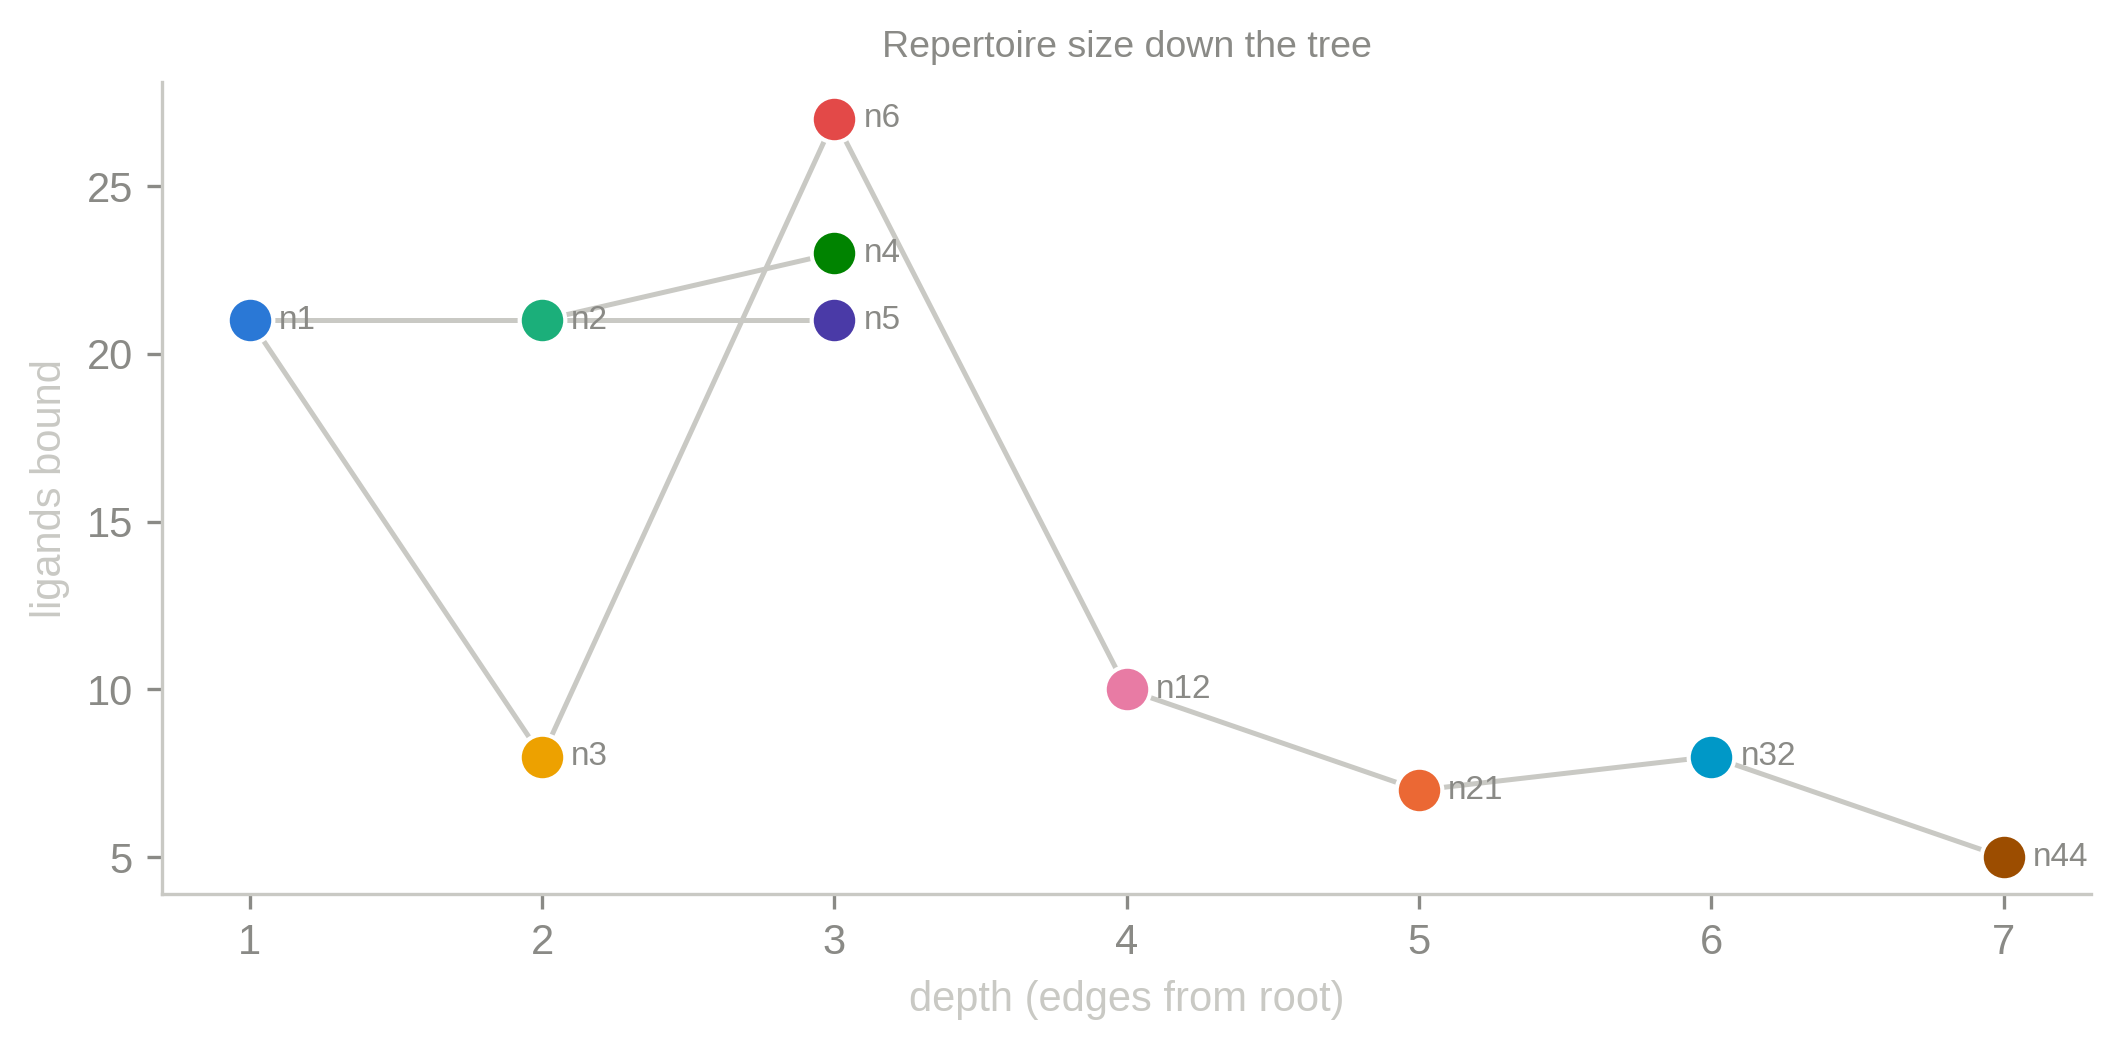

In [2]:
nearest = {}
for r in topo.itertuples():
    within = [int(a) for a in r.ancestors_in_set.split(";") if a]
    nearest[r.node] = max(within, key=lambda m: int(topo.loc[topo.node == m, "depth"].iloc[0])) \
                      if within else None

depth = dict(zip(topo.node, topo.depth))
nlig = dict(zip(topo.node, topo.n_ligands))

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
for n, p in nearest.items():
    if p is not None:
        ax.plot([depth[p], depth[n]], [nlig[p], nlig[n]], color="#c9c9c4", lw=1.2, zorder=1)
for r in topo.itertuples():
    ax.scatter(r.depth, r.n_ligands, s=120, color=NCOL[r.node], zorder=3,
               edgecolor="white", lw=1.0)
    ax.annotate(f"n{r.node}", (r.depth, r.n_ligands), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_xlabel("depth (edges from root)"); ax.set_ylabel("ligands bound")
ax.set_title("Repertoire size down the tree", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_lineage"); plt.show()

## OR class of each node

Assigned from the classes of the descendant human leaves: >=90% class I is class I,
<=10% is class II, anything between is mixed.

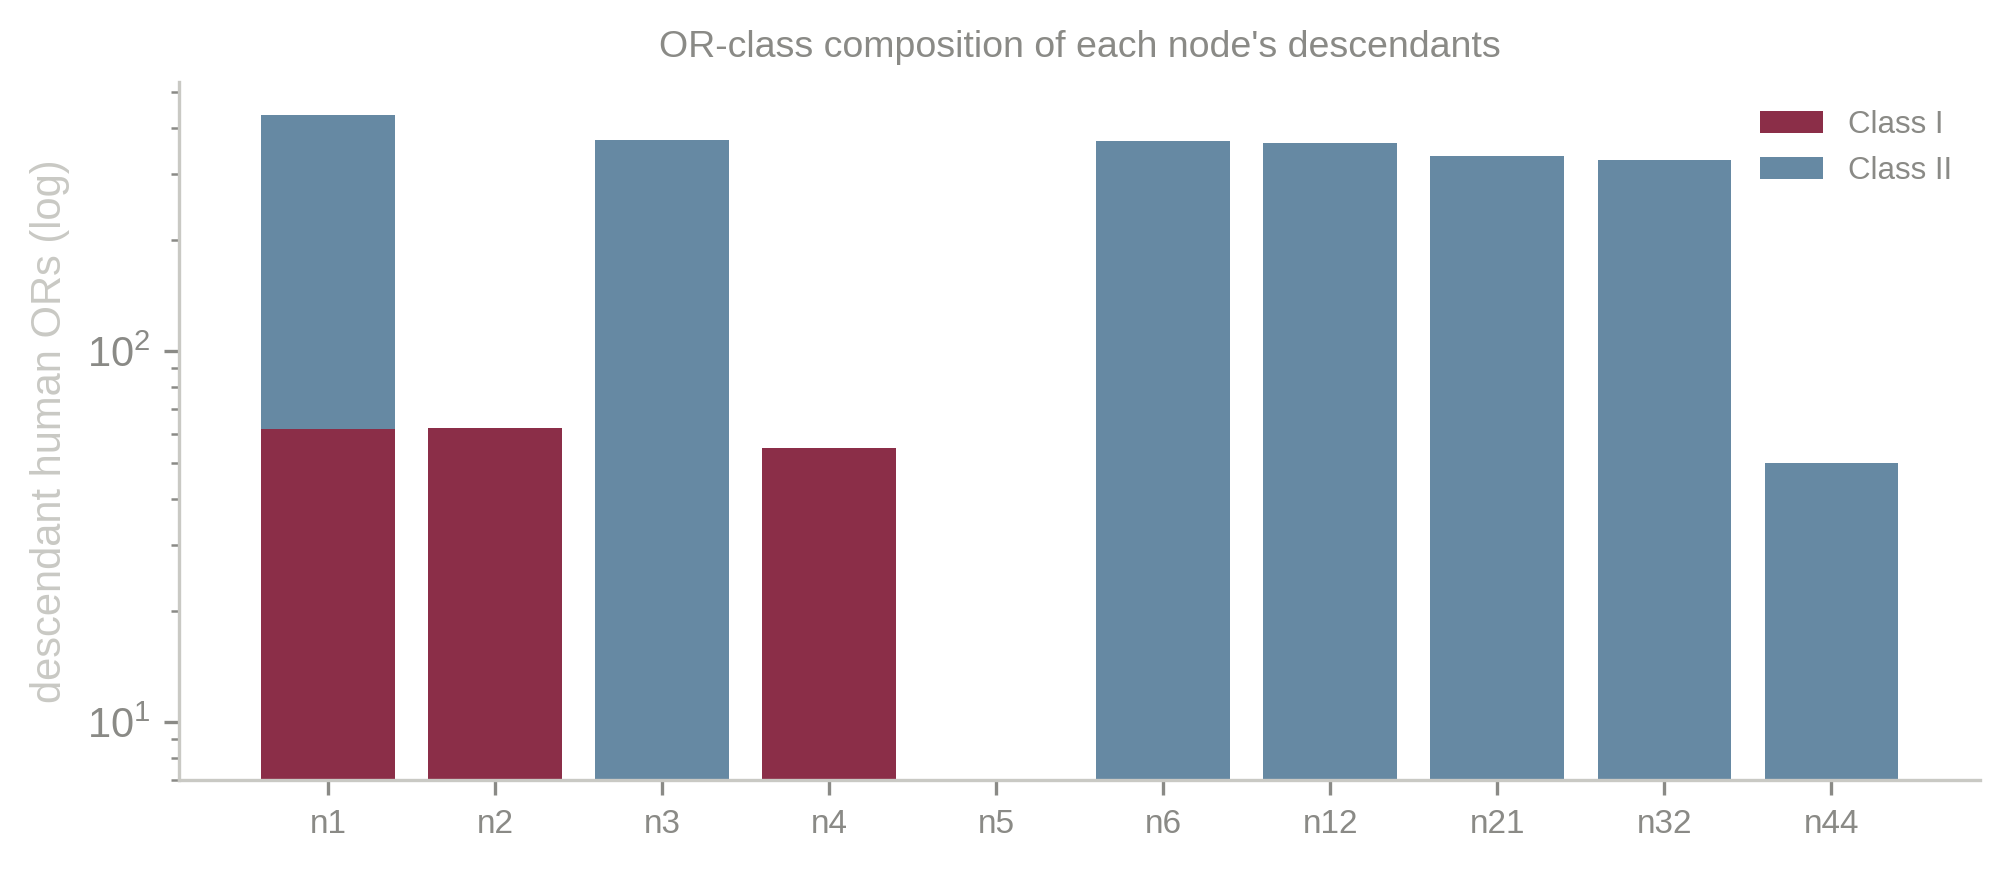

 node OR_class  n_leaves  frac_class_I  n_ligands
    1    mixed       433         0.143         21
    2  Class_I        62         1.000         21
    3 Class_II       371         0.000          8
    4  Class_I        55         1.000         23
    5  Class_I         7         1.000         21
    6 Class_II       370         0.000         27
   12 Class_II       365         0.000         10
   21 Class_II       337         0.000          7
   32 Class_II       328         0.000          8
   44 Class_II        50         0.000          5


In [3]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.7, FIGSIZE[1]))
x = np.arange(len(topo))
n_i = topo.frac_class_I * topo.n_leaves
n_ii = (1 - topo.frac_class_I) * topo.n_leaves
ax.bar(x, n_i, color=CLASS1_COL, label="Class I", alpha=0.9)
ax.bar(x, n_ii, bottom=n_i, color=CLASS2_COL, label="Class II", alpha=0.9)
ax.set_yscale("log"); ax.set_ylabel("descendant human ORs (log)")
ax.set_xticks(x); ax.set_xticklabels([f"n{n}" for n in topo.node], fontsize=8)
ax.legend(frameon=False, fontsize=7.5)
ax.set_title("OR-class composition of each node's descendants", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_node_or_class"); plt.show()

print(topo[["node", "OR_class", "n_leaves", "frac_class_I", "n_ligands"]].to_string(index=False))

## Overlap between the ten repertoires

union of the ten: 61 ligands
bound by all ten: 1 ligands


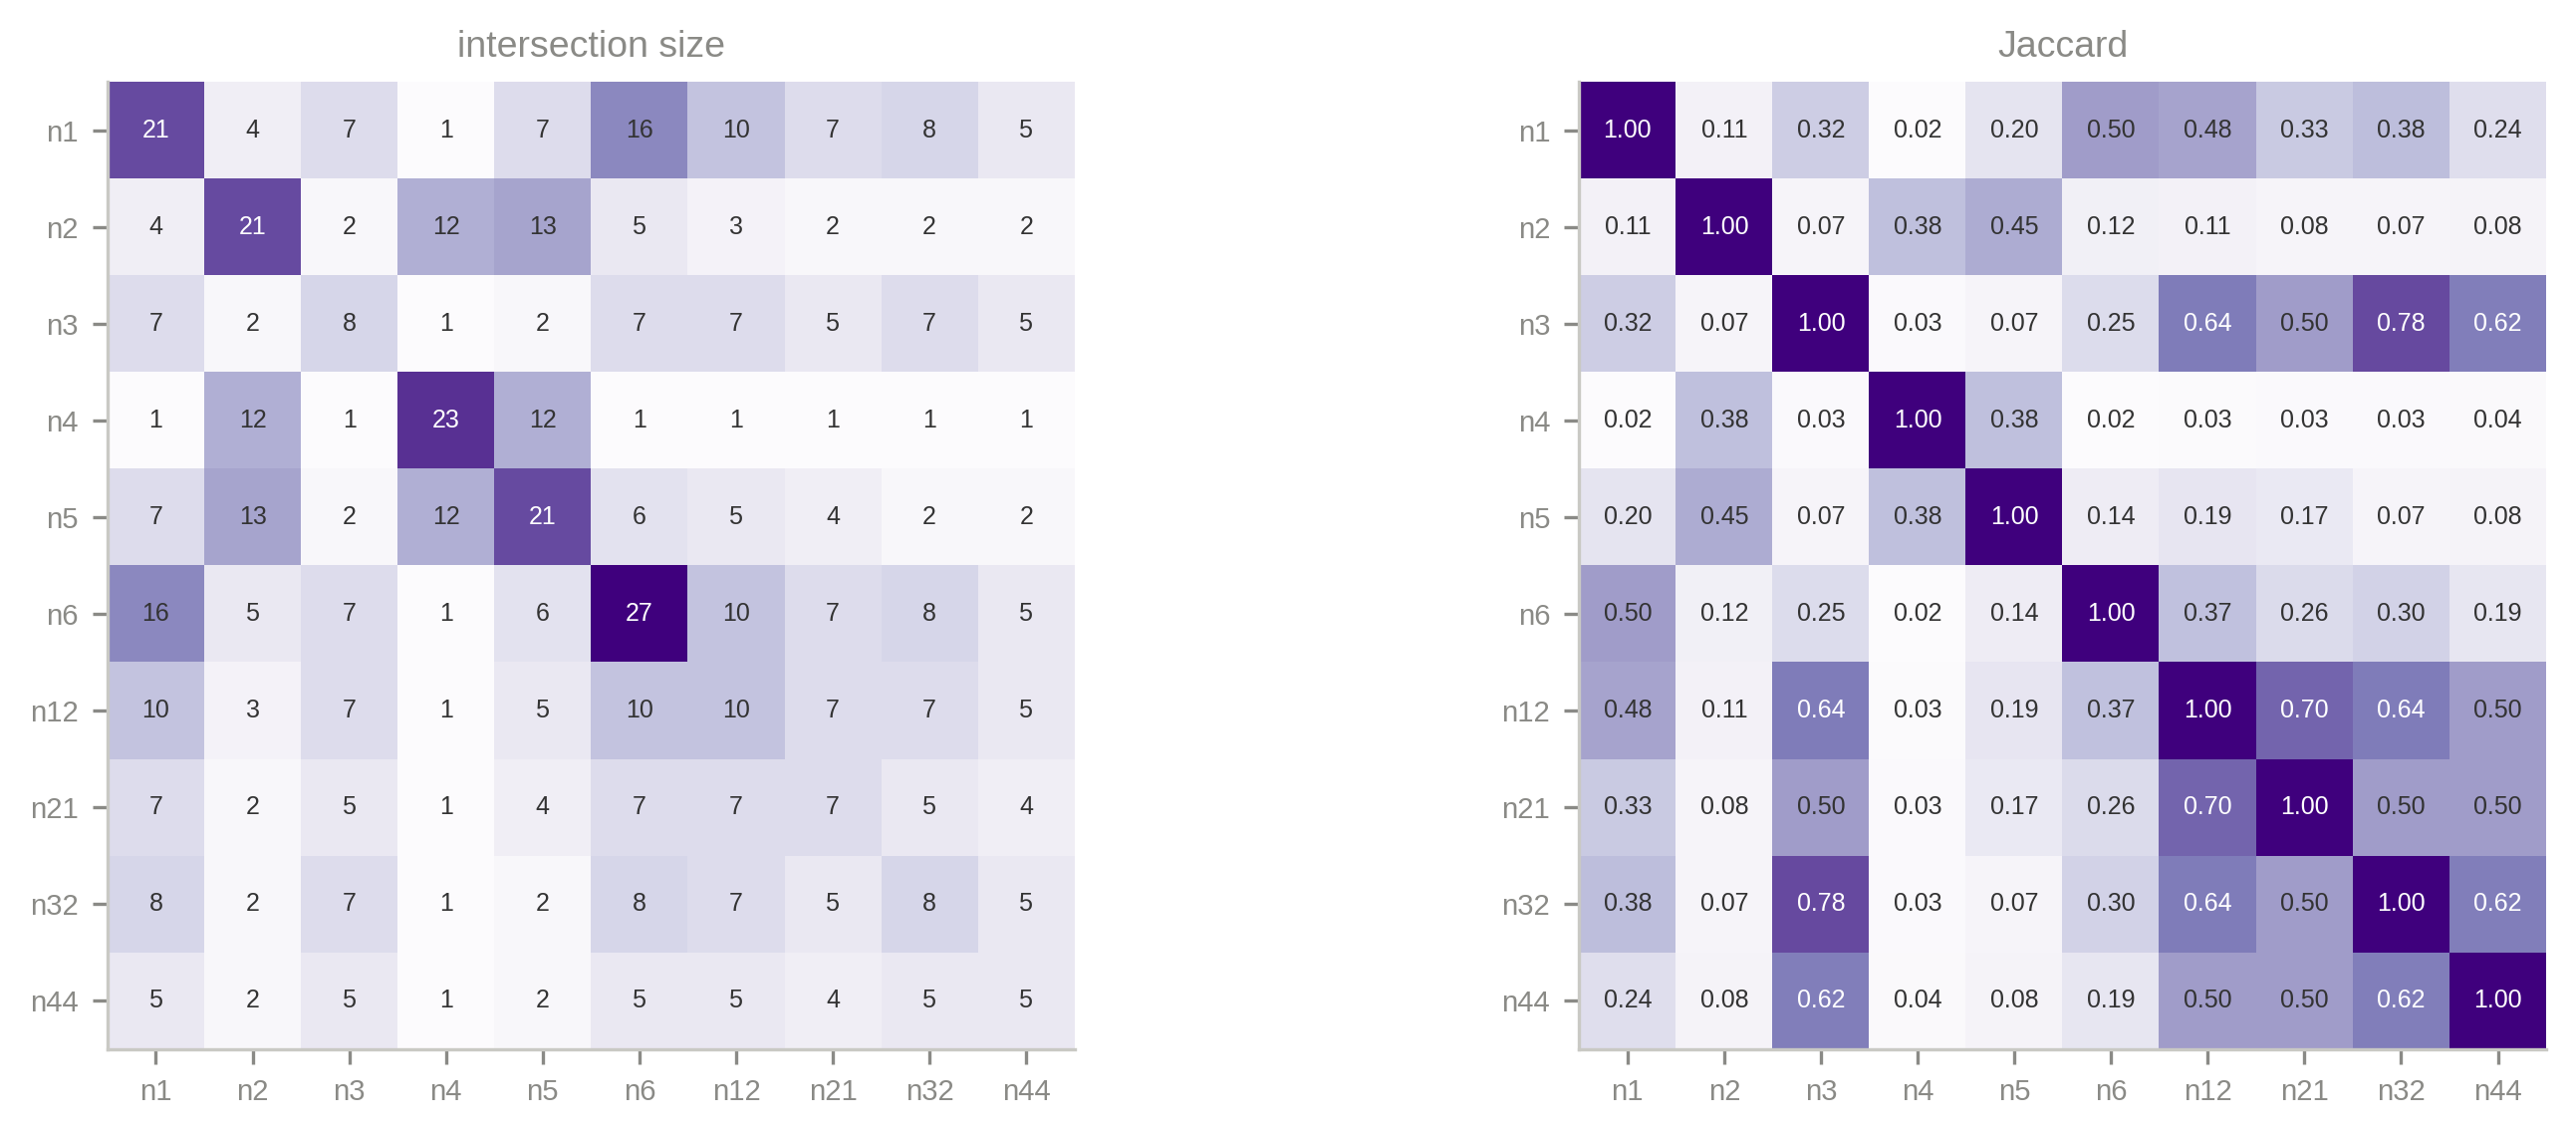

In [4]:
J = pd.DataFrame(index=TEN_NODES, columns=TEN_NODES, dtype=float)
I = pd.DataFrame(index=TEN_NODES, columns=TEN_NODES, dtype=int)
for a in TEN_NODES:
    for b in TEN_NODES:
        inter = len(sets[a] & sets[b]); union = len(sets[a] | sets[b])
        I.loc[a, b] = inter
        J.loc[a, b] = inter / union if union else 0.0
save_table(J.round(4).reset_index().rename(columns={"index": "node"}), "05_pairwise_jaccard")

union_all = set().union(*sets.values())
print(f"union of the ten: {len(union_all)} ligands")
print(f"bound by all ten: {len(set.intersection(*sets.values()))} ligands")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.6, FIGSIZE[1] * 1.3))
for ax, M, title, fmt in [(axes[0], I.astype(float), "intersection size", ".0f"),
                          (axes[1], J.astype(float), "Jaccard", ".2f")]:
    im = ax.imshow(M.values, cmap="Purples")
    ax.set_xticks(range(len(TEN_NODES))); ax.set_yticks(range(len(TEN_NODES)))
    ax.set_xticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
    ax.set_yticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
    cut = M.values.max() * 0.6
    for i in range(len(TEN_NODES)):
        for j in range(len(TEN_NODES)):
            ax.text(j, i, format(M.values[i, j], fmt), ha="center", va="center",
                    fontsize=6, color="white" if M.values[i, j] > cut else "#333")
    ax.set_title(title, fontsize=9)
plt.tight_layout(); save_fig(fig, "05_pairwise_overlap"); plt.show()

## Intersection structure

Which combinations of nodes share a ligand. Because the nodes are nested, most ligands
fall into a small number of patterns.

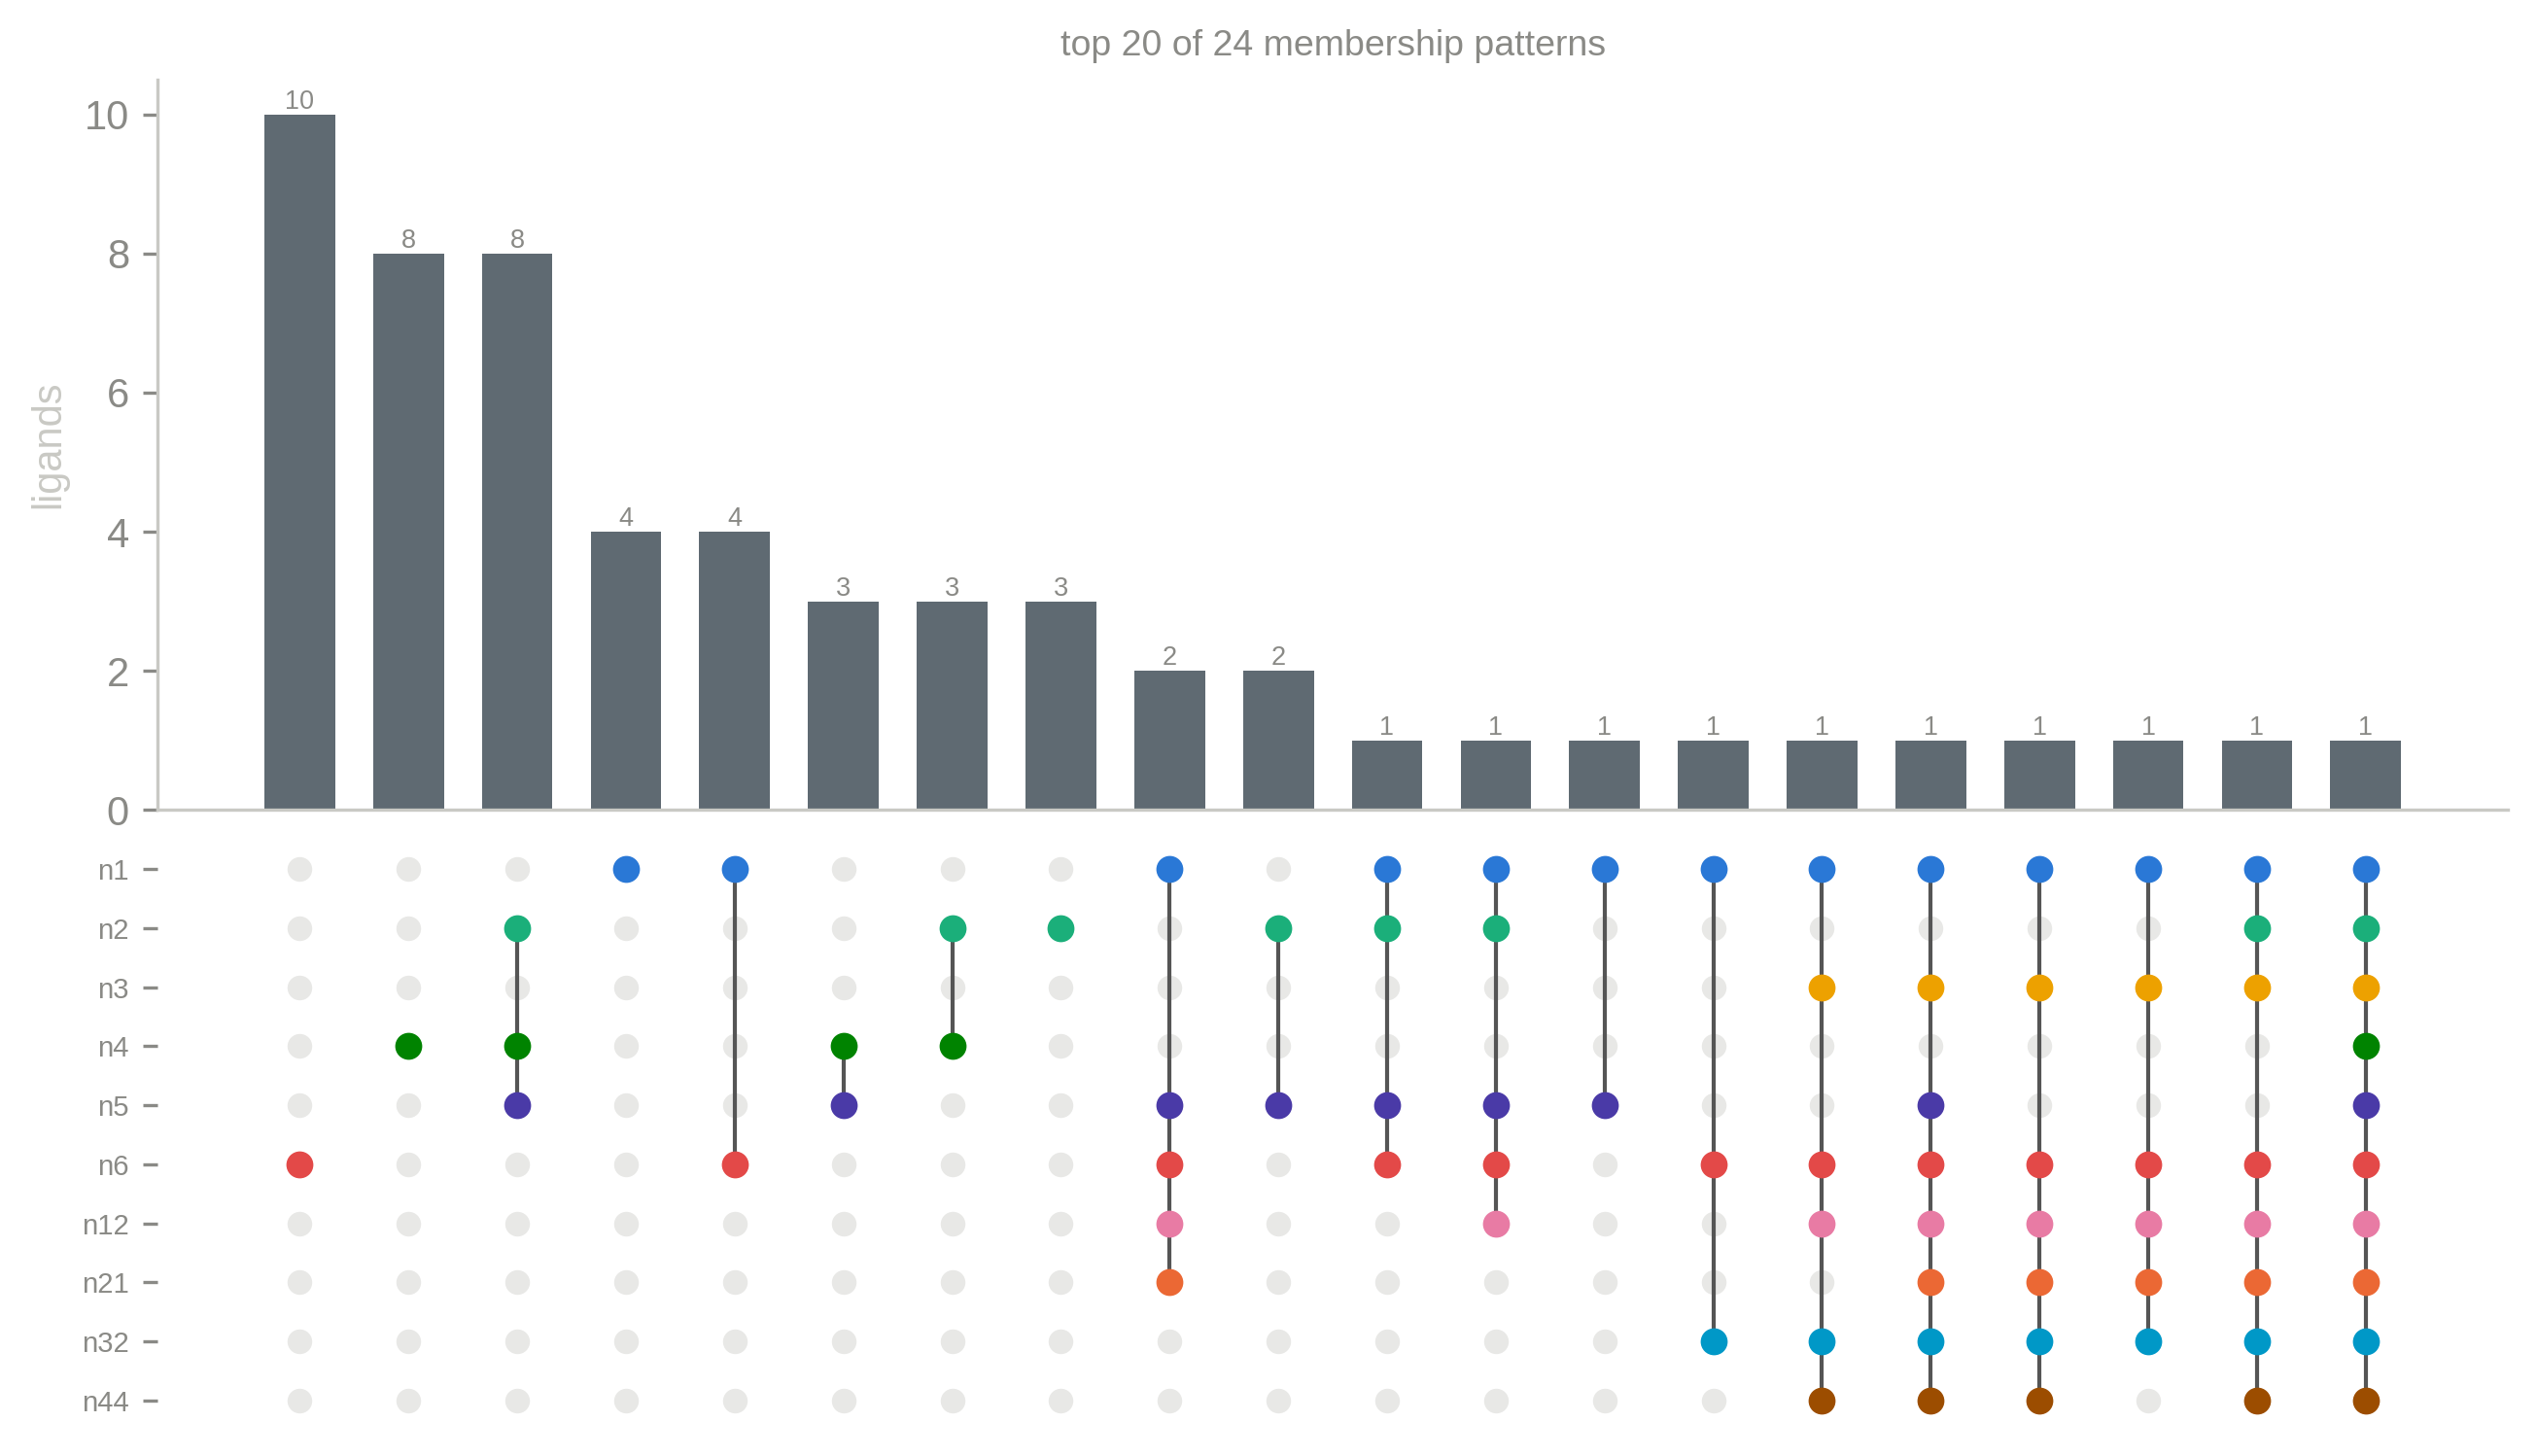

In [5]:
member = {s: tuple(s in sets[n] for n in TEN_NODES) for s in union_all}
counts = pd.Series(list(member.values())).value_counts()
top = counts.head(20)

fig = plt.figure(figsize=(FIGSIZE[0] * 2.6, FIGSIZE[1] * 2.0))
gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.6], hspace=0.05)
axb = fig.add_subplot(gs[0]); axm = fig.add_subplot(gs[1], sharex=axb)

xs = np.arange(len(top))
axb.bar(xs, top.values, color="#5F6A72", width=0.65)
for xi, v in zip(xs, top.values):
    axb.text(xi, v, str(v), ha="center", va="bottom", fontsize=6.5)
axb.set_ylabel("ligands"); axb.tick_params(labelbottom=False)

for yi, n in enumerate(TEN_NODES):
    axm.scatter(xs, [yi] * len(xs), s=26, color="#e8e8e6", zorder=1)
    on = [xi for xi, m in zip(xs, top.index) if m[yi]]
    axm.scatter(on, [yi] * len(on), s=32, color=NCOL[n], zorder=3)
for xi, m in zip(xs, top.index):
    idx = [yi for yi in range(len(TEN_NODES)) if m[yi]]
    if len(idx) > 1:
        axm.plot([xi, xi], [min(idx), max(idx)], color="#555", lw=1.0, zorder=2)
axm.set_yticks(range(len(TEN_NODES)))
axm.set_yticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
axm.set_xticks([]); axm.invert_yaxis()
for sp in ["top", "right", "bottom", "left"]: axm.spines[sp].set_visible(False)
axb.set_title(f"top {len(top)} of {len(counts)} membership patterns", fontsize=9)
save_fig(fig, "05_upset"); plt.show()

## Gains and losses against the immediate parent

The parent comes from the full ASR matrix, so it need not itself be one of the ten.

 node  parent  n_ligands  n_retained  n_gained  n_lost
    2  node_1         21         4.0      17.0    17.0
    3  node_1          8         7.0       1.0    14.0
    4  node_2         23        12.0      11.0     9.0
    5  node_2         21        13.0       8.0     8.0
    6  node_3         27         7.0      20.0     1.0
   12  node_6         10        10.0       0.0    17.0
   21 node_12          7         7.0       0.0     3.0
   32 node_21          8         5.0       3.0     2.0
   44 node_32          5         5.0       0.0     3.0


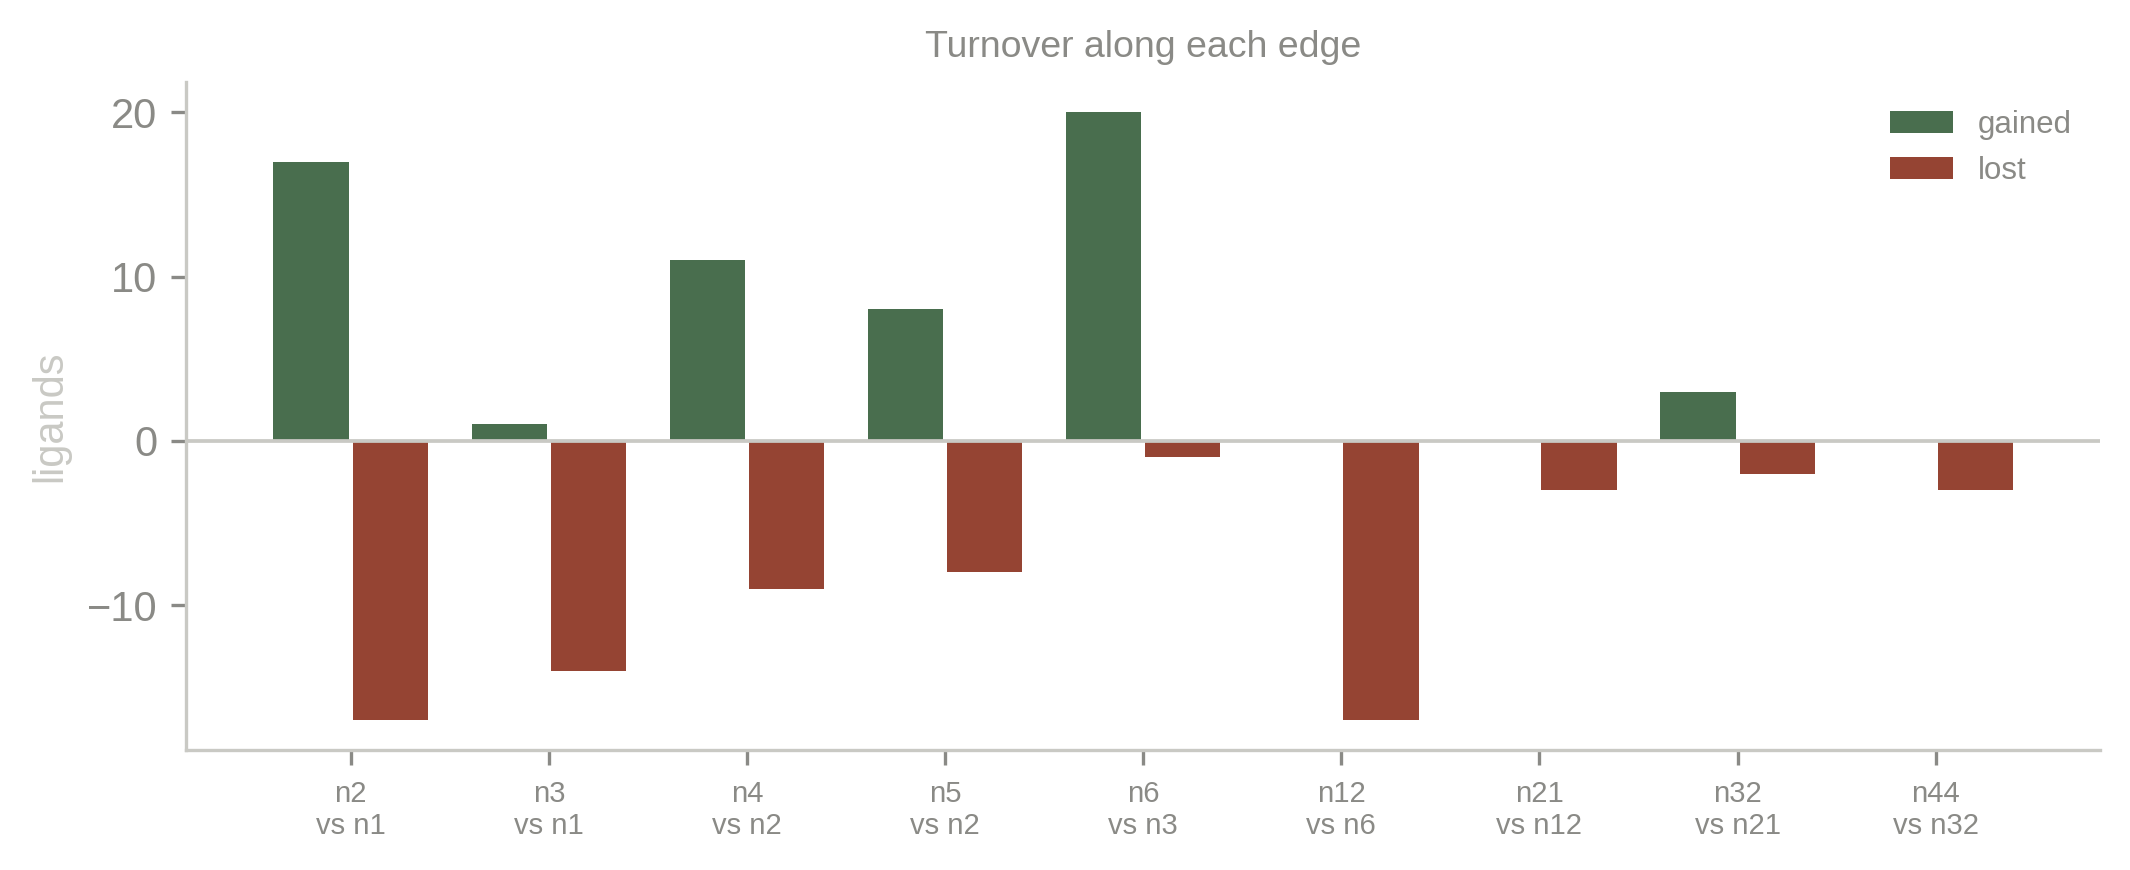

In [6]:
gl = topo.dropna(subset=["n_gained"])
print(gl[["node", "parent", "n_ligands", "n_retained", "n_gained", "n_lost"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1]))
x = np.arange(len(gl))
ax.bar(x - 0.2, gl.n_gained, 0.38, color="#355E3B", label="gained", alpha=0.9)
ax.bar(x + 0.2, -gl.n_lost, 0.38, color="#8A2F1D", label="lost", alpha=0.9)
ax.axhline(0, color="#c9c9c4", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"n{r.node}\nvs {r.parent.replace('node_', 'n')}" for r in gl.itertuples()],
                   fontsize=7)
ax.set_ylabel("ligands"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Turnover along each edge", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_gain_loss"); plt.show()

## Chemistry of each node's repertoire

Descriptors first, then functional-group prevalence as a heatmap across all ten.

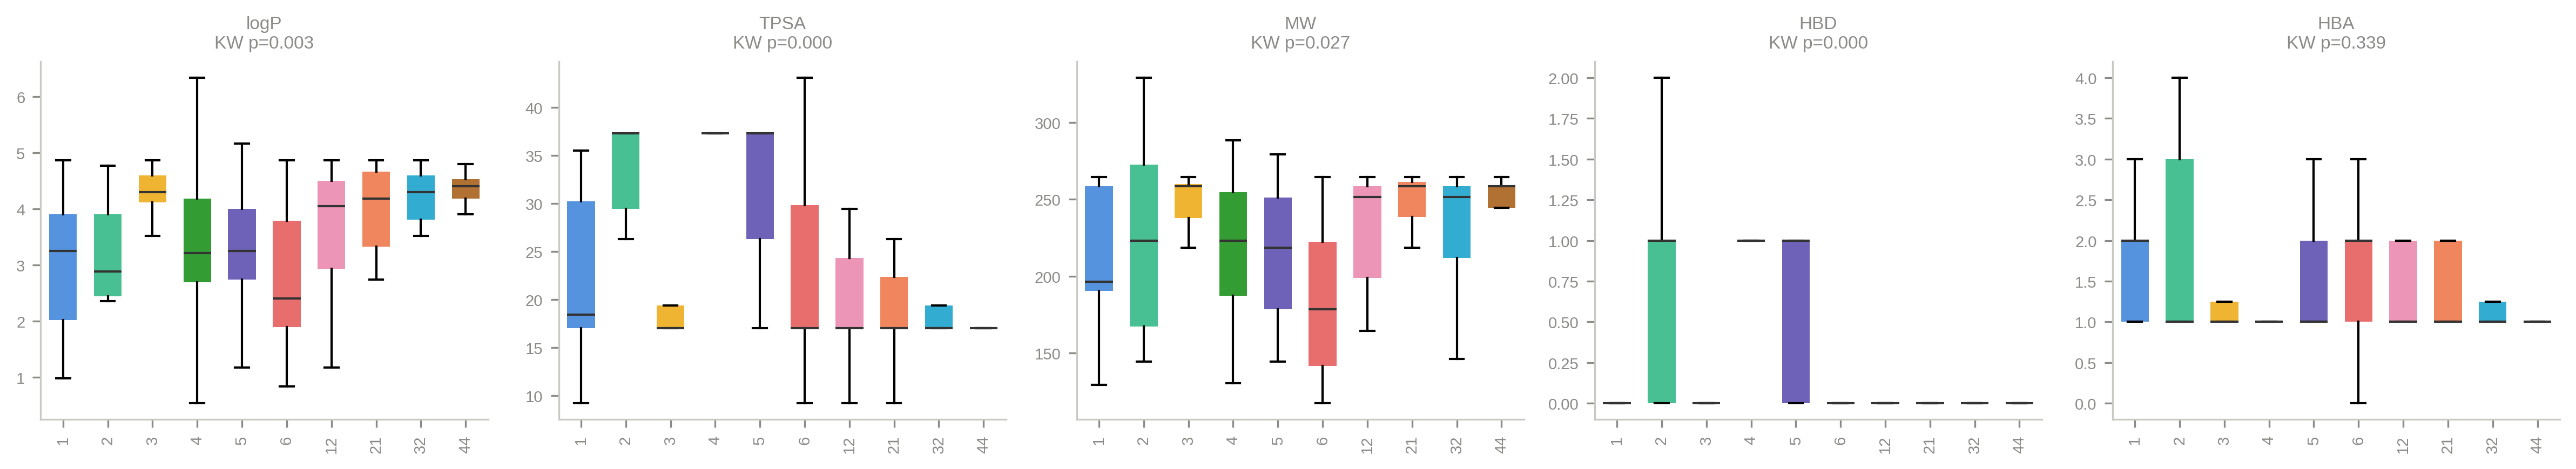

In [7]:
chem = descriptors(sorted(union_all)).merge(functional_groups(sorted(union_all)), on="SMILES")
FG_COLS = list(FG_SMARTS)

fig, axes = plt.subplots(1, len(DESCRIPTORS),
                         figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.8, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [chem[chem.SMILES.isin(sets[n])][d].dropna().values for n in TEN_NODES]
    bp = ax.boxplot(data, widths=0.62, patch_artist=True, showfliers=False,
                    medianprops=dict(color="#333"))
    for patch, n in zip(bp["boxes"], TEN_NODES):
        patch.set_facecolor(NCOL[n]); patch.set_alpha(0.8); patch.set_edgecolor("none")
    h, p = kruskal(*data)
    ax.set_title(f"{d}\nKW p={p:.3f}", fontsize=8)
    ax.set_xticks(range(1, len(TEN_NODES) + 1))
    ax.set_xticklabels([str(n) for n in TEN_NODES], fontsize=6, rotation=90)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "05_node_descriptors"); plt.show()

                   1     2     3     4     5     6     12    21    32    44
carboxylic_acid   0.0  47.6   0.0  82.6  57.1   0.0   0.0   0.0   0.0   0.0
alcohol           4.8  14.3   0.0   4.3  14.3   3.7  10.0  14.3   0.0   0.0
aldehyde          4.8   9.5   0.0   4.3   4.8   3.7   0.0   0.0   0.0   0.0
ketone           42.9  14.3  62.5   8.7   4.8  37.0  50.0  42.9  62.5  60.0
ester            28.6   9.5  25.0   0.0  14.3  18.5  20.0  28.6  12.5  20.0
ether            52.4  23.8  37.5   4.3  28.6  37.0  50.0  57.1  25.0  40.0
amine             0.0  14.3   0.0   4.3   4.8   7.4   0.0   0.0   0.0   0.0
amide             4.8   4.8   0.0   4.3   4.8   0.0   0.0   0.0   0.0   0.0
aromatic_ring    61.9  33.3  50.0   8.7  23.8  70.4  60.0  57.1  62.5  60.0
phenol            4.8  14.3   0.0   8.7   4.8   3.7  10.0   0.0   0.0   0.0
nitrile           0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
alkene           57.1  33.3  25.0  13.0  38.1  33.3  50.0  42.9  25.0  20.0


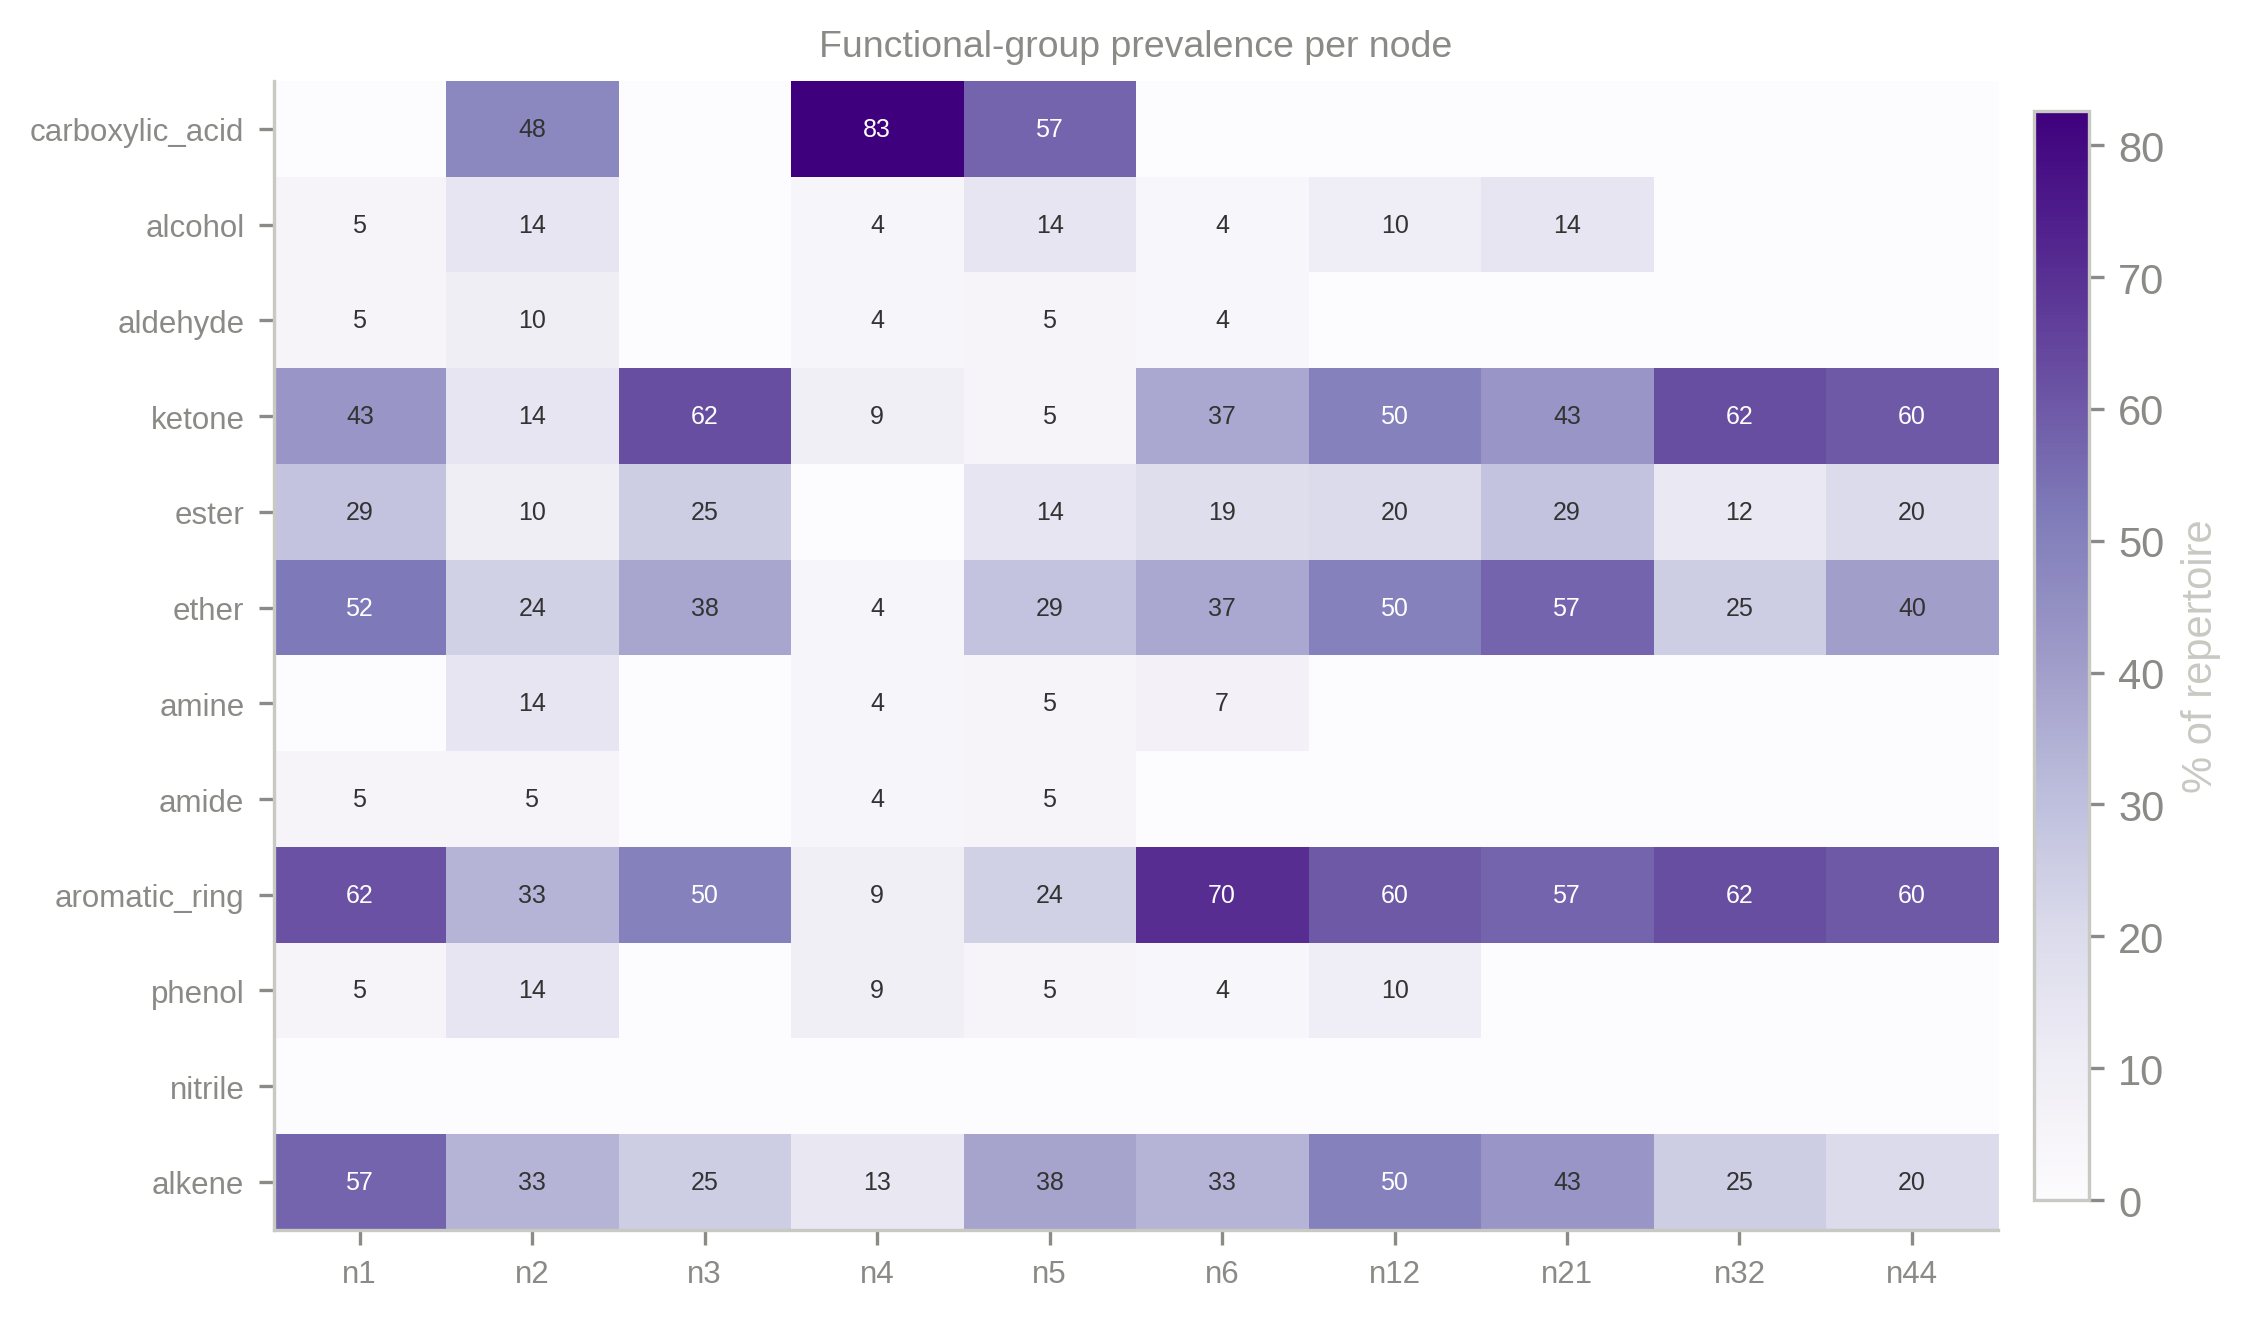

In [8]:
prev = pd.DataFrame({n: chem[chem.SMILES.isin(sets[n])][FG_COLS].mean() * 100
                     for n in TEN_NODES})
print(prev.round(1).to_string())
save_table(prev.reset_index().rename(columns={"index": "functional_group"}),
           "05_functional_groups")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.9, FIGSIZE[1] * 1.5))
im = ax.imshow(prev.values, cmap="Purples", aspect="auto", vmin=0)
ax.set_xticks(range(len(TEN_NODES)))
ax.set_xticklabels([f"n{n}" for n in TEN_NODES], fontsize=7.5)
ax.set_yticks(range(len(prev))); ax.set_yticklabels(prev.index, fontsize=7.5)
cut = prev.values.max() * 0.6
for i in range(len(prev)):
    for j in range(len(TEN_NODES)):
        v = prev.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6,
                    color="white" if v > cut else "#333")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="% of repertoire")
ax.set_title("Functional-group prevalence per node", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_functional_groups"); plt.show()